In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

sns.set_theme(style="whitegrid")

monthly = pd.read_csv("data/processed/monthly_pin_level.csv")
baseline = pd.read_csv("data/processed/pincode_baseline_stats.csv")
anoms = pd.read_csv("data/processed/final_anomalies.csv")

monthly['month'] = pd.to_datetime(monthly['month'])
anoms['month'] = pd.to_datetime(anoms['month'])


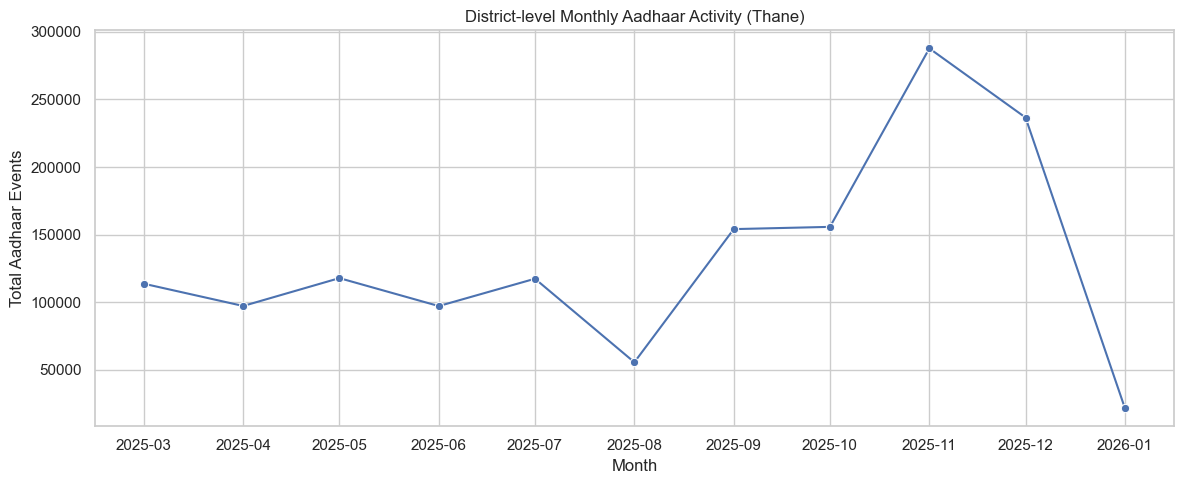

In [2]:
district_monthly = (
    monthly
    .groupby('month', as_index=False)
    .agg(total_activity=('total_monthly_count','sum'))
)

plt.figure(figsize=(12,5))
sns.lineplot(
    data=district_monthly,
    x='month',
    y='total_activity',
    marker='o'
)
plt.title("District-level Monthly Aadhaar Activity (Thane)")
plt.xlabel("Month")
plt.ylabel("Total Aadhaar Events")
plt.tight_layout()
plt.show()


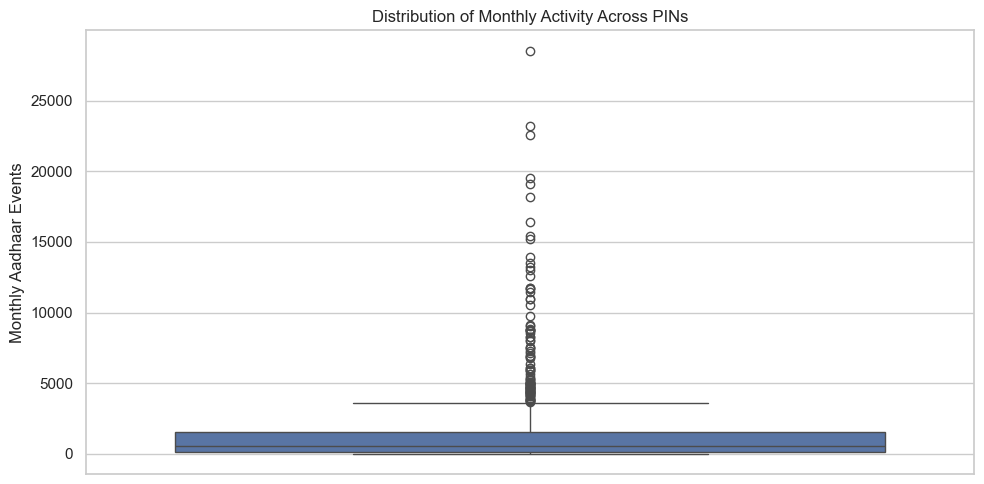

In [3]:
plt.figure(figsize=(10,5))
sns.boxplot(
    data=monthly,
    y='total_monthly_count'
)
plt.title("Distribution of Monthly Activity Across PINs")
plt.ylabel("Monthly Aadhaar Events")
plt.tight_layout()
plt.show()


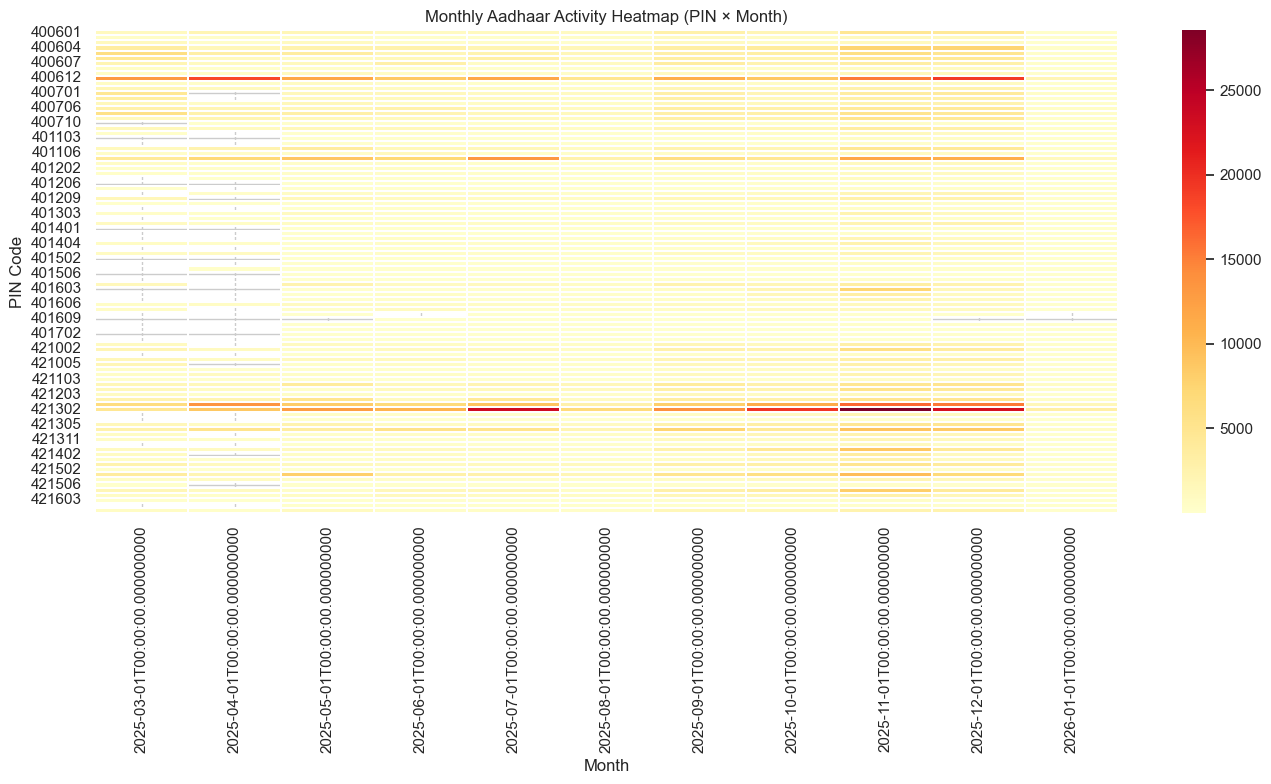

In [4]:
pivot = monthly.pivot_table(
    index='pincode',
    columns='month',
    values='total_monthly_count',
    aggfunc='sum'
)

plt.figure(figsize=(14,8))
sns.heatmap(
    pivot,
    cmap="YlOrRd",
    linewidths=0.1
)
plt.title("Monthly Aadhaar Activity Heatmap (PIN × Month)")
plt.xlabel("Month")
plt.ylabel("PIN Code")
plt.tight_layout()
plt.show()


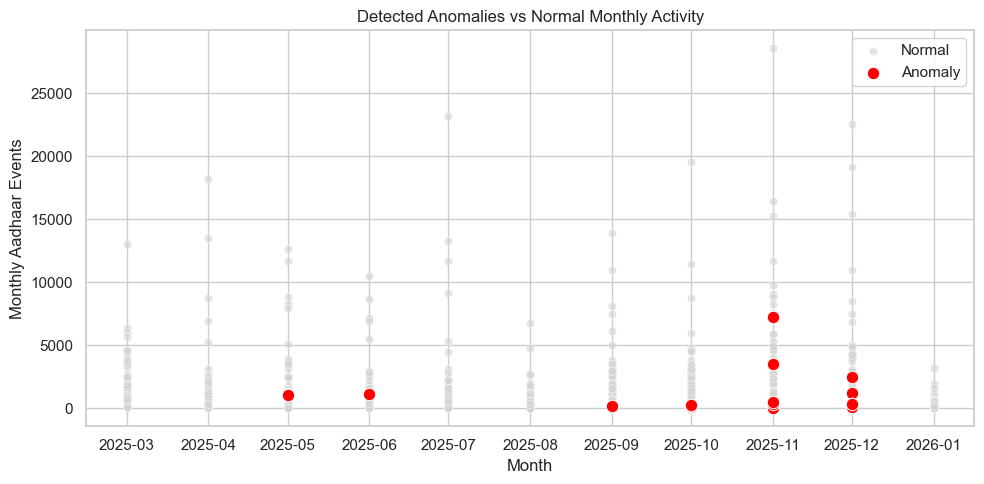

In [5]:
plt.figure(figsize=(10,5))

sns.scatterplot(
    data=monthly,
    x='month',
    y='total_monthly_count',
    color='lightgray',
    alpha=0.6,
    label='Normal'
)

sns.scatterplot(
    data=anoms,
    x='month',
    y='total_monthly_count',
    color='red',
    s=80,
    label='Anomaly'
)

plt.title("Detected Anomalies vs Normal Monthly Activity")
plt.xlabel("Month")
plt.ylabel("Monthly Aadhaar Events")
plt.legend()
plt.tight_layout()
plt.show()


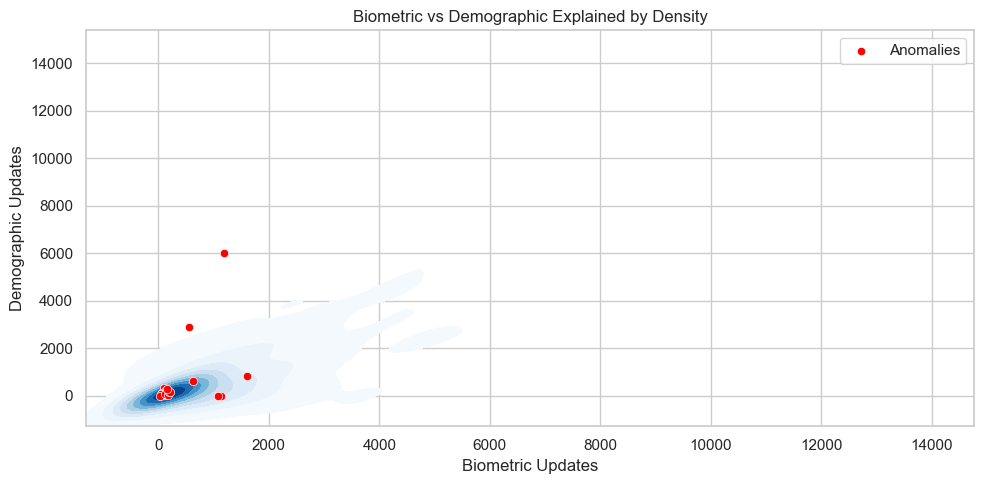

In [6]:
plt.figure(figsize=(10,5))

sns.kdeplot(
    data=monthly,
    x='bio_updates',
    y='demo_updates',
    cmap="Blues",
    fill=True,
    thresh=0.05
)

sns.scatterplot(
    data=anoms,
    x='bio_updates',
    y='demo_updates',
    color='red',
    label='Anomalies'
)

plt.title("Biometric vs Demographic Explained by Density")
plt.xlabel("Biometric Updates")
plt.ylabel("Demographic Updates")
plt.legend()
plt.tight_layout()
plt.show()


C:\Users\Naman\AppData\Local\Temp\ipykernel_11772\3824518476.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


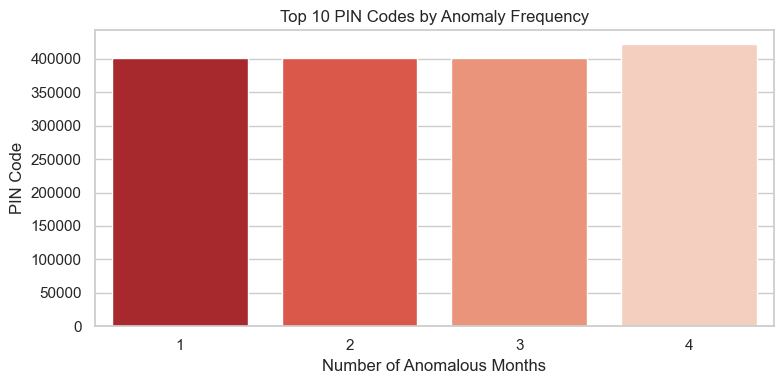

In [7]:
top_pins = (
    anoms['pincode']
    .value_counts()
    .head(10)
    .reset_index()
)
top_pins.columns = ['pincode','anomaly_count']

plt.figure(figsize=(8,4))
sns.barplot(
    data=top_pins,
    x='anomaly_count',
    y='pincode',
    palette='Reds_r'
)
plt.title("Top 10 PIN Codes by Anomaly Frequency")
plt.xlabel("Number of Anomalous Months")
plt.ylabel("PIN Code")
plt.tight_layout()
plt.show()
